# Tutorial 12 — Agentic RAG: Multi-Tool Scientific Research Agent
**Author:** Himanshu Goel | [Website](https://himanshugoel.github.io)

**Agentic RAG** goes far beyond vanilla RAG by giving an LLM a *toolbelt* and letting it decide:
- **Which sources to query** — PubMed, arXiv, Semantic Scholar, or the open web
- **Which papers to fully index** — fetch & chunk only the most promising results
- **When to search vs. synthesize** — retrieves evidence iteratively before writing an answer

### Available tools
| Tool | Source | Purpose |
|------|--------|---------|
| `pubmed_search` | NCBI E-utilities | Discover peer-reviewed papers by query |
| `fetch_and_index_paper` | PMC full-text XML | Fetch a paper by PMID and index into vector DB |
| `arxiv_search` | arXiv API | Find preprints and ML/CS methods |
| `semantic_scholar_search` | Semantic Scholar API | Cross-domain search + citation counts |
| `web_search` | DuckDuckGo | General web results — docs, news, blogs |
| `fetch_url` | Any URL | Parse & index any webpage |
| `vector_search` | ChromaDB | Semantic search over all indexed content |
| `crossref_lookup` | CrossRef API | DOI → journal / author / citation metadata |

### Vanilla RAG vs Agentic RAG
| Aspect | Vanilla RAG | Agentic RAG |
|--------|-------------|-------------|
| Knowledge source | Fixed pre-indexed corpus | Dynamically searched at query time |
| Retrieval strategy | Single one-shot lookup | Multi-step, tool-guided |
| Coverage | Pre-indexed documents only | Live internet + multiple databases |
| Multi-hop reasoning | Limited | Yes — agent chains tool calls |
| Source diversity | One database | PubMed + arXiv + Semantic Scholar + Web |

In [64]:
!pip install openai chromadb sentence-transformers -q
!pip install duckduckgo-search beautifulsoup4 requests python-dotenv -q
!pip install 'transformers>=4.41.0,<5.0' -q

import transformers; print('transformers', transformers.__version__)
import openai;       print('openai      ', openai.__version__)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=83145) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=83145) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=83145) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
transformers 4.57.6
openai       2.33.0


In [65]:
!pip install pdfplumber python-pptx pillow -q
!pip install networkx matplotlib pyvis -q
!pip install gradio -q

import networkx;   print('networkx   ', networkx.__version__)
import pdfplumber; print('pdfplumber ', pdfplumber.__version__)
import gradio;     print('gradio     ', gradio.__version__)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=83145) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=83145) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=83145) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
networkx    3.6.1
pdfplumber  0.11.9
gradio      6.14.0


In [66]:
import os, json, re, time, hashlib
import requests
import xml.etree.ElementTree as ET
import urllib.parse

import chromadb
from openai import OpenAI
from sentence_transformers import SentenceTransformer
from dotenv import load_dotenv

load_dotenv()  # reads OPENAI_API_KEY (and optional NCBI_API_KEY) from .env

OPENAI_API_KEY = os.getenv('OPENAI_API_KEY', '')
NCBI_API_KEY   = os.getenv('NCBI_API_KEY', '')  # optional: 10 req/s vs 3 req/s

# ── Embedding model (local, no API key needed) ────────────────────────────────
# all-MiniLM-L6-v2: 22M params, fast, good enough for retrieval
print('Loading embedding model...')
embedder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
print('Embedding model ready.')

# ── In-memory ChromaDB vector store ──────────────────────────────────────────
# EphemeralClient avoids SQLite file-lock issues when re-running cells
chroma_client = chromadb.EphemeralClient()
collection    = chroma_client.get_or_create_collection(
    name='agentic_rag',
    metadata={'hnsw:space': 'cosine'}
)

# ── OpenAI client ─────────────────────────────────────────────────────────────
client = OpenAI(api_key=OPENAI_API_KEY)

# ── Agent state ───────────────────────────────────────────────────────────────
_indexed_ids: set[str] = set()  # track already-indexed doc IDs (idempotency)

print(f'Vector DB ready. OpenAI client ready.')
print(f'NCBI API key: {"set" if NCBI_API_KEY else "not set (3 req/s limit applies)"}')

Loading embedding model...
Embedding model ready.
Vector DB ready. OpenAI client ready.
NCBI API key: not set (3 req/s limit applies)


In [67]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import pathlib, base64

KG = nx.DiGraph()

KG_TYPE_COLORS = {
    'Method':  '#4CAF50', 'Drug':    '#2196F3', 'Protein': '#FF9800',
    'Paper':   '#9C27B0', 'Author':  '#F44336', 'Dataset': '#00BCD4',
    'Concept': '#795548', 'Disease': '#E91E63', 'Unknown': '#9E9E9E',
}

print('Knowledge graph ready.')

Knowledge graph ready.


## Step 1 — Define the Tools

Each tool is a plain Python function. The agent will choose which ones to call and with what arguments. Results flow back into the conversation as `tool_result` messages.

In [68]:
# ─────────────────────────────────────────────────────────────────────────────
# Tool 1: pubmed_search
#
# Queries NCBI PubMed via the E-utilities esearch + efetch API.
# Returns lightweight metadata (title, abstract snippet, PMID, PMC ID, DOI)
# so the agent can decide which papers are worth fully indexing.
# ─────────────────────────────────────────────────────────────────────────────
def tool_pubmed_search(query: str, max_results: int = 10) -> dict:
    base   = 'https://eutils.ncbi.nlm.nih.gov/entrez/eutils/'
    params = {'db': 'pubmed', 'term': query, 'retmax': max_results, 'retmode': 'json'}
    if NCBI_API_KEY:
        params['api_key'] = NCBI_API_KEY

    try:
        r    = requests.get(f'{base}esearch.fcgi', params=params, timeout=15)
        pmids = r.json()['esearchresult']['idlist']
    except Exception as e:
        return {'error': str(e), 'results': []}

    if not pmids:
        return {'results': [], 'count': 0}

    fetch = requests.get(
        f'{base}efetch.fcgi',
        params={'db': 'pubmed', 'id': ','.join(pmids), 'rettype': 'abstract', 'retmode': 'xml'},
        timeout=20
    )
    root    = ET.fromstring(fetch.text)
    results = []
    for art in root.iter('PubmedArticle'):
        pmid  = art.findtext('.//PMID', '')
        title = ''.join(''.join(t.itertext()) for t in art.iter('ArticleTitle'))
        abstr = ''.join(''.join(t.itertext()) for t in art.iter('AbstractText'))[:400]
        year  = art.findtext('.//PubDate/Year', '?')
        pmcid = art.findtext(".//ArticleId[@IdType='pmc']", '')
        doi   = art.findtext(".//ArticleId[@IdType='doi']", '')
        results.append({
            'pmid': pmid, 'title': title[:120], 'abstract_snippet': abstr,
            'year': year, 'pmcid': pmcid, 'doi': doi,
            'has_fulltext': bool(pmcid)
        })

    return {'results': results, 'count': len(results)}


# Quick smoke test
demo = tool_pubmed_search('SILCS binding affinity drug discovery', max_results=3)
print(f"PubMed returned {demo['count']} results")
for r in demo['results']:
    print(f"  [{r['year']}] PMID {r['pmid']} | full-text={r['has_fulltext']} | {r['title'][:70]}...")

PubMed returned 3 results
  [2023] PMID 37218059 | full-text=True | Ranking mAb-excipient interactions in biologics formulations by NMR sp...
  [2022] PMID 35913731 | full-text=True | SILCS-RNA: Toward a Structure-Based Drug Design Approach for Targeting...
  [2022] PMID 35210743 | full-text=True | Application of Site-Identification by Ligand Competitive Saturation in...


In [69]:
# ─────────────────────────────────────────────────────────────────────────────
# Tool 2: fetch_and_index_paper
#
# Given a PMID:
#   1. Fetches the full article XML from PubMed Central if it's open-access
#   2. Falls back to the abstract if no full text is available
#   3. Splits into 700-char chunks (100-char overlap)
#   4. Embeds and inserts every chunk into ChromaDB
#
# Re-indexing the same PMID is a no-op (idempotent).
# ─────────────────────────────────────────────────────────────────────────────
def tool_fetch_and_index_paper(pmid: str) -> dict:
    if pmid in _indexed_ids:
        return {'status': 'already_indexed', 'pmid': pmid}

    base = 'https://eutils.ncbi.nlm.nih.gov/entrez/eutils/'
    try:
        fetch = requests.get(
            f'{base}efetch.fcgi',
            params={'db': 'pubmed', 'id': pmid, 'rettype': 'abstract', 'retmode': 'xml'},
            timeout=20
        )
        root = ET.fromstring(fetch.text)
    except Exception as e:
        return {'status': 'error', 'pmid': pmid, 'error': str(e)}

    art = root.find('.//PubmedArticle')
    if art is None:
        return {'status': 'not_found', 'pmid': pmid}

    title = ''.join(''.join(t.itertext()) for t in art.iter('ArticleTitle'))
    abstr = ''.join(''.join(t.itertext()) for t in art.iter('AbstractText'))
    year  = art.findtext('.//PubDate/Year', '?')
    pmcid = art.findtext(".//ArticleId[@IdType='pmc']", '')
    doi   = art.findtext(".//ArticleId[@IdType='doi']", '')

    content = None
    source  = 'abstract'

    if pmcid:
        try:
            pmc      = requests.get(
                f'{base}efetch.fcgi',
                params={'db': 'pmc', 'id': pmcid, 'rettype': 'xml', 'retmode': 'xml'},
                timeout=25
            )
            pmc_root = ET.fromstring(pmc.text)
            sections = []
            for sec in pmc_root.iter('sec'):
                sec_title = sec.findtext('title', '').strip()
                sec_text  = ' '.join(''.join(p.itertext()) for p in sec.iter('p')).strip()
                if sec_text:
                    sections.append(f'[{sec_title or "Section"}]\n{sec_text}')
            if sections:
                content = f'Title: {title}\n\n' + '\n\n'.join(sections)
                source  = 'fulltext'
            time.sleep(0.35)   # NCBI rate limit: stay under 3 req/s unauthenticated
        except Exception:
            pass

    if content is None:
        if abstr.strip():
            content = f'Title: {title}\n\nAbstract: {abstr}'
        else:
            return {'status': 'no_content', 'pmid': pmid}

    # ── Chunk into overlapping segments ──────────────────────────────────────
    chunk_size, overlap = 700, 100
    chunks = []
    for i in range(0, len(content), chunk_size - overlap):
        chunk = content[i: i + chunk_size].strip()
        if chunk:
            chunks.append(chunk)

    # ── Embed and upsert into ChromaDB ────────────────────────────────────────
    embeddings = embedder.encode(chunks).tolist()
    ids        = [f'pmid_{pmid}_{j}' for j in range(len(chunks))]
    metas      = [{'pmid': pmid, 'pmcid': pmcid, 'title': title[:100],
                   'year': year, 'source': source, 'doi': doi}
                  for _ in chunks]
    collection.upsert(documents=chunks, embeddings=embeddings, ids=ids, metadatas=metas)

    _indexed_ids.add(pmid)
    return {
        'status': 'indexed', 'pmid': pmid, 'title': title[:100],
        'source': source, 'chunks_added': len(chunks),
        'total_in_db': collection.count()
    }


# Test: fetch and index the first result from the previous search
if demo['results']:
    test_pmid = demo['results'][0]['pmid']
    result    = tool_fetch_and_index_paper(test_pmid)
    print(result)

{'status': 'indexed', 'pmid': '37218059', 'title': 'Ranking mAb-excipient interactions in biologics formulations by NMR spectroscopy and computational a', 'source': 'fulltext', 'chunks_added': 153, 'total_in_db': 2378}


In [70]:
# ─────────────────────────────────────────────────────────────────────────────
# Tool 3: arxiv_search
#
# Queries the arXiv Atom feed API — free, no key required.
# Great for finding recent ML/CS preprints that haven't hit PubMed yet.
# Automatically embeds and indexes each abstract into ChromaDB.
# ─────────────────────────────────────────────────────────────────────────────
def tool_arxiv_search(query: str, max_results: int = 5) -> dict:
    url = (
        f'https://export.arxiv.org/api/query'
        f'?search_query=all:{urllib.parse.quote(query)}'
        f'&max_results={max_results}&sortBy=relevance'
    )
    try:
        r    = requests.get(url, timeout=15)
        root = ET.fromstring(r.text)
    except Exception as e:
        return {'error': str(e), 'results': []}

    ns      = {'atom': 'http://www.w3.org/2005/Atom'}
    results = []
    for entry in root.findall('atom:entry', ns):
        arxiv_id  = entry.findtext('atom:id', '', ns).split('/abs/')[-1]
        title     = entry.findtext('atom:title', '', ns).strip().replace('\n', ' ')
        summary   = entry.findtext('atom:summary', '', ns).strip().replace('\n', ' ')
        published = entry.findtext('atom:published', '', ns)[:10]
        authors   = [a.findtext('atom:name', '', ns)
                     for a in entry.findall('atom:author', ns)][:4]

        # Index abstract in ChromaDB
        doc_id  = f'arxiv_{arxiv_id.replace("/", "_")}'
        content = f'Title: {title}\n\nAbstract: {summary}'
        if doc_id not in _indexed_ids:
            emb = embedder.encode([content]).tolist()
            collection.upsert(
                documents=[content], embeddings=emb, ids=[doc_id],
                metadatas=[{'arxiv_id': arxiv_id, 'title': title[:100],
                            'year': published[:4], 'source': 'arxiv',
                            'pmid': '', 'pmcid': ''}]
            )
            _indexed_ids.add(doc_id)

        results.append({
            'arxiv_id': arxiv_id, 'title': title[:120],
            'abstract_snippet': summary[:300], 'published': published,
            'authors': authors
        })

    return {'results': results, 'count': len(results), 'indexed': len(results)}


demo_arxiv = tool_arxiv_search('protein ligand binding deep learning', max_results=3)
def tool_arxiv_search(query: str, max_results: int = 5) -> dict:
    url = (
        f'https://export.arxiv.org/api/query'
        f'?search_query=all:{urllib.parse.quote(query)}'
        f'&max_results={max_results}&sortBy=relevance'
    )
    try:
        r    = requests.get(url, timeout=15)
        root = ET.fromstring(r.text)
    except Exception as e:
        return {'error': str(e), 'results': [], 'count': 0}

    ns      = {'atom': 'http://www.w3.org/2005/Atom'}
    results = []
    for entry in root.findall('atom:entry', ns):
        arxiv_id  = entry.findtext('atom:id', '', ns).split('/abs/')[-1]
        title     = entry.findtext('atom:title', '', ns).strip().replace('\n', ' ')
        summary   = entry.findtext('atom:summary', '', ns).strip().replace('\n', ' ')
        published = entry.findtext('atom:published', '', ns)[:10]
        authors   = [a.findtext('atom:name', '', ns)
                     for a in entry.findall('atom:author', ns)][:4]

        # Index abstract in ChromaDB
        doc_id  = f'arxiv_{arxiv_id.replace("/", "_")}'
        content = f'Title: {title}\n\nAbstract: {summary}'
        if doc_id not in _indexed_ids:
            emb = embedder.encode([content]).tolist()
            collection.upsert(
                documents=[content], embeddings=emb, ids=[doc_id],
                metadatas=[{'arxiv_id': arxiv_id, 'title': title[:100],
                            'year': published[:4], 'source': 'arxiv',
                            'pmid': '', 'pmcid': ''}]
            )
            _indexed_ids.add(doc_id)

        results.append({
            'arxiv_id': arxiv_id, 'title': title[:120],
            'abstract_snippet': summary[:300], 'published': published,
            'authors': authors
        })

    return {'results': results, 'count': len(results), 'indexed': len(results)}


demo_arxiv = tool_arxiv_search('protein ligand binding deep learning', max_results=3)
print(f"arXiv returned {demo_arxiv.get('count', 0)} results")
for r in demo_arxiv['results']:
    print(f"  [{r['published']}] arXiv:{r['arxiv_id']} | {r['title'][:70]}...")
for r in demo_arxiv['results']:
    print(f"  [{r['published']}] arXiv:{r['arxiv_id']} | {r['title'][:70]}...")

arXiv returned 3 results
  [2024-05-23] arXiv:2405.14108v7 | Assessing the potential of deep learning for protein-ligand docking...
  [2017-11-22] arXiv:1711.10540v2 | ISLAND: In-Silico Prediction of Proteins Binding Affinity Using Sequen...
  [2023-06-19] arXiv:2306.11113v2 | Learn to Accumulate Evidence from All Training Samples: Theory and Pra...
  [2024-05-23] arXiv:2405.14108v7 | Assessing the potential of deep learning for protein-ligand docking...
  [2017-11-22] arXiv:1711.10540v2 | ISLAND: In-Silico Prediction of Proteins Binding Affinity Using Sequen...
  [2023-06-19] arXiv:2306.11113v2 | Learn to Accumulate Evidence from All Training Samples: Theory and Pra...


In [71]:
# ─────────────────────────────────────────────────────────────────────────────
# Tool 4: semantic_scholar_search
#
# Queries the Semantic Scholar Graph API (free, no key required).
# Returns citation counts — useful for identifying influential papers.
# Cross-domain: covers computer science, medicine, biology, physics, etc.
# ─────────────────────────────────────────────────────────────────────────────
def tool_semantic_scholar_search(query: str, max_results: int = 5) -> dict:
    try:
        r = requests.get(
            'https://api.semanticscholar.org/graph/v1/paper/search',
            params={
                'query': query, 'limit': max_results,
                'fields': 'title,abstract,year,authors,citationCount,externalIds'
            },
            headers={'User-Agent': 'AgenticRAG/1.0 (educational use)'},
            timeout=15
        )
    except Exception as e:
        return {'error': str(e), 'results': [], 'count': 0}

    if r.status_code != 200:
        return {'error': f'HTTP {r.status_code}', 'results': [], 'count': 0}

    results = []
    for p in r.json().get('data', []):
        paper_id = p.get('paperId', '')
        title    = p.get('title', '')
        abstract = (p.get('abstract') or '')[:400]
        year     = p.get('year', '?')
        cites    = p.get('citationCount', 0)
        pmid     = p.get('externalIds', {}).get('PubMed', '')

        if abstract:
            doc_id  = f'ss_{paper_id}'
            content = f'Title: {title}\n\nAbstract: {abstract}'
            if doc_id not in _indexed_ids:
                emb = embedder.encode([content]).tolist()
                collection.upsert(
                    documents=[content], embeddings=emb, ids=[doc_id],
                    metadatas=[{'ss_id': paper_id, 'title': title[:100],
                                'year': str(year), 'source': 'semantic_scholar',
                                'pmid': pmid, 'pmcid': '', 'citations': str(cites)}]
                )
                _indexed_ids.add(doc_id)

        results.append({
            'paper_id': paper_id, 'title': title[:120],
            'abstract_snippet': abstract[:200], 'year': year,
            'citations': cites, 'pmid': pmid
        })

    return {'results': results, 'count': len(results)}


demo_s2 = tool_semantic_scholar_search('SILCS fragment binding free energy', max_results=3)
print(f"Semantic Scholar returned {demo_s2['count']} results")
for r in demo_s2['results']:
    print(f"  [{r['year']}] {r['citations']} citations | {r['title'][:70]}...")

Semantic Scholar returned 0 results


In [72]:
# ─────────────────────────────────────────────────────────────────────────────
# Tool 5: web_search
#
# DuckDuckGo search — no API key required.
# Returns up to max_results snippets with URL and title.
# Use for documentation, news, blog posts, or any non-academic query.
# ─────────────────────────────────────────────────────────────────────────────
def tool_web_search(query: str, max_results: int = 5) -> dict:
    try:
        from duckduckgo_search import DDGS
        with DDGS() as ddgs:
            raw = list(ddgs.text(query, max_results=max_results))
        return {
            'results': [
                {'title': r.get('title', ''),
                 'url':   r.get('href', ''),
                 'snippet': r.get('body', '')[:300]}
                for r in raw
            ],
            'count': len(raw)
        }
    except Exception as e:
        return {'error': str(e), 'results': []}


# ─────────────────────────────────────────────────────────────────────────────
# Tool 6: fetch_url
#
# Fetches a URL, strips HTML tags with BeautifulSoup, and indexes the
# extracted text into ChromaDB for downstream vector_search queries.
# Useful when the agent finds a relevant page via web_search.
# ─────────────────────────────────────────────────────────────────────────────
def tool_fetch_url(url: str, max_chars: int = 3000) -> dict:
    try:
        from bs4 import BeautifulSoup
        headers = {'User-Agent': 'Mozilla/5.0 (compatible; AgenticRAG/1.0)'}
        r       = requests.get(url, headers=headers, timeout=20)
        soup    = BeautifulSoup(r.text, 'html.parser')
        for tag in soup(['script', 'style', 'nav', 'footer', 'header', 'aside']):
            tag.decompose()
        text = soup.get_text(separator='\n', strip=True)
        text = re.sub(r'\n{3,}', '\n\n', text)[:max_chars]

        # get_text() handles nested tags safely; .string returns None for multi-child elements
        page_title = soup.title.get_text(strip=True) if soup.title else url[:80]

        # hashlib.md5 is stable across restarts; hash() uses a random seed per process
        doc_id = 'web_' + hashlib.md5(url.encode()).hexdigest()[:12]
        emb    = embedder.encode([text]).tolist()
        collection.upsert(
            documents=[text], embeddings=emb, ids=[doc_id],
            metadatas=[{'url': url, 'source': 'web', 'title': page_title[:100],
                        'pmid': '', 'pmcid': '', 'year': '?'}]
        )
        _indexed_ids.add(doc_id)

        return {'url': url, 'title': page_title, 'content_preview': text[:500],
                'chars_indexed': len(text), 'total_in_db': collection.count()}
    except Exception as e:
        return {'error': str(e), 'url': url}


print('web_search and fetch_url tools defined.')

web_search and fetch_url tools defined.


In [73]:
# ─────────────────────────────────────────────────────────────────────────────
# Tool 9: load_local_file
#
# Loads any local document and indexes its content into ChromaDB.
# Supported formats:
#   .pdf        — pdfplumber extracts text page-by-page (tables included)
#   .pptx/.ppt  — python-pptx extracts slide text + speaker notes
#   .html/.htm  — BeautifulSoup parses local HTML files
#   .png/.jpg/.jpeg/.webp/.gif — GPT-4o vision describes the image content
#
# All extracted text is chunked and upserted into ChromaDB exactly like
# web pages or PubMed abstracts — vector_search queries work across them.
# ─────────────────────────────────────────────────────────────────────────────
_IMAGE_MIME = {
    'png':  'image/png', 'jpg':  'image/jpeg', 'jpeg': 'image/jpeg',
    'webp': 'image/webp', 'gif': 'image/gif',  'bmp':  'image/bmp',
}

def tool_load_local_file(file_path: str) -> dict:
    path = pathlib.Path(file_path).expanduser().resolve()
    if not path.exists():
        return {'error': f'File not found: {file_path}'}

    ext          = path.suffix.lower().lstrip('.')
    content      = ''
    source_label = ext

    # ── PDF ──────────────────────────────────────────────────────────────────
    if ext == 'pdf':
        import pdfplumber
        pages = []
        with pdfplumber.open(str(path)) as pdf:
            for i, page in enumerate(pdf.pages):
                text = page.extract_text() or ''
                # Also try to extract tables as plain text rows
                for table in page.extract_tables():
                    rows = [' | '.join(str(c) for c in row if c) for row in table if row]
                    text += '\n' + '\n'.join(rows)
                if text.strip():
                    pages.append(f'[Page {i+1}]\n{text.strip()}')
        content = '\n\n'.join(pages)

    # ── PowerPoint ───────────────────────────────────────────────────────────
    elif ext in ('pptx', 'ppt'):
        from pptx import Presentation
        prs    = Presentation(str(path))
        slides = []
        for i, slide in enumerate(prs.slides):
            parts = []
            for shape in slide.shapes:
                if shape.has_text_frame:
                    parts.append(shape.text_frame.text.strip())
            # Include speaker notes if present
            if slide.has_notes_slide:
                notes = slide.notes_slide.notes_text_frame.text.strip()
                if notes:
                    parts.append(f'[Notes] {notes}')
            if parts:
                slides.append(f'[Slide {i+1}]\n' + '\n'.join(p for p in parts if p))
        content = '\n\n'.join(slides)

    # ── Local HTML ───────────────────────────────────────────────────────────
    elif ext in ('html', 'htm'):
        from bs4 import BeautifulSoup
        raw  = path.read_text(encoding='utf-8', errors='ignore')
        soup = BeautifulSoup(raw, 'html.parser')
        for tag in soup(['script', 'style', 'nav', 'footer', 'header', 'aside']):
            tag.decompose()
        content = soup.get_text(separator='\n', strip=True)
        content = re.sub(r'\n{3,}', '\n\n', content)
        source_label = 'html_local'

    # ── Image (GPT-4o vision) ─────────────────────────────────────────────────
    elif ext in _IMAGE_MIME:
        mime    = _IMAGE_MIME[ext]
        img_b64 = base64.b64encode(path.read_bytes()).decode()
        resp    = client.chat.completions.create(
            model='gpt-4o',
            max_tokens=1024,
            messages=[{
                'role': 'user',
                'content': [
                    {
                        'type': 'image_url',
                        'image_url': {'url': f'data:{mime};base64,{img_b64}', 'detail': 'high'}
                    },
                    {
                        'type': 'text',
                        'text': (
                            'Describe this image in full scientific detail. '
                            'Extract every piece of text, all axis labels, figure captions, '
                            'table contents, equations, and numerical values visible. '
                            'Explain what the figure or diagram shows scientifically.'
                        )
                    }
                ]
            }]
        )
        content      = f'[Image: {path.name}]\n\n' + resp.choices[0].message.content
        source_label = 'image'

    else:
        supported = 'pdf, pptx, html, ' + ', '.join(_IMAGE_MIME.keys())
        return {'error': f'Unsupported extension ".{ext}". Supported: {supported}'}

    if not content.strip():
        return {'error': 'No text content extracted', 'file': str(path)}

    # ── Chunk and index into ChromaDB ─────────────────────────────────────────
    chunk_size, overlap = 700, 100
    chunks = []
    for i in range(0, len(content), chunk_size - overlap):
        chunk = content[i: i + chunk_size].strip()
        if chunk:
            chunks.append(chunk)

    file_id    = 'file_' + hashlib.md5(str(path).encode()).hexdigest()[:12]
    embeddings = embedder.encode(chunks).tolist()
    ids        = [f'{file_id}_{j}' for j in range(len(chunks))]
    metas      = [{'source': source_label, 'title': path.stem, 'file': path.name,
                   'pmid': '', 'pmcid': '', 'year': '?'}
                  for _ in chunks]
    collection.upsert(documents=chunks, embeddings=embeddings, ids=ids, metadatas=metas)
    _indexed_ids.add(file_id)

    return {
        'file':          path.name,
        'type':          source_label,
        'pages_slides':  content.count('[Page ') + content.count('[Slide '),
        'chars':         len(content),
        'chunks_indexed': len(chunks),
        'total_in_db':   collection.count(),
        'preview':       content[:300],
    }


print('tool_load_local_file ready — supports: pdf, pptx, html, png/jpg/webp (vision)')

tool_load_local_file ready — supports: pdf, pptx, html, png/jpg/webp (vision)


In [74]:
from difflib import SequenceMatcher
import networkx.algorithms.community as nx_comm
import csv as _csv

# ══════════════════════════════════════════════════════════════════════════════
# Internal helpers
# ══════════════════════════════════════════════════════════════════════════════

def _find_similar_node(name: str, entity_type: str = '', threshold: float = 0.85) -> str | None:
    """
    Return the canonical existing node that is similar enough to `name`.
    Checks substring containment first (fast), then edit-distance similarity.
    Only matches across the same entity type (or Unknown) to avoid false merges.
    """
    name_l = name.lower().strip()
    best, best_score = None, 0.0
    for node in KG.nodes():
        node_type = KG.nodes[node].get('type', 'Unknown')
        if entity_type and node_type not in ('Unknown', entity_type):
            continue
        node_l = node.lower().strip()
        # Substring: one fully contains the other
        if name_l in node_l or node_l in name_l:
            ratio = min(len(name_l), len(node_l)) / max(len(name_l), len(node_l), 1)
            if ratio > 0.55 and ratio > best_score:
                best_score, best = ratio, node
        else:
            sim = SequenceMatcher(None, name_l, node_l).ratio()
            if sim >= threshold and sim > best_score:
                best_score, best = sim, node
    return best


def _detect_communities() -> dict[str, int]:
    """Return {node: community_id} using Louvain (falls back to greedy modularity)."""
    if KG.number_of_nodes() < 2:
        return {n: 0 for n in KG.nodes()}
    ug = KG.to_undirected()
    try:
        comms = nx_comm.louvain_communities(ug, seed=42)
    except Exception:
        comms = list(nx_comm.greedy_modularity_communities(ug))
    return {node: i for i, comm in enumerate(comms) for node in comm}


def _community_colors(n: int) -> list[str]:
    """Generate n distinct hex colours from the tab20 colormap."""
    import matplotlib.cm as cm
    cmap = cm.get_cmap('tab20', max(n, 1))
    colors = []
    for i in range(n):
        r, g, b, _ = cmap(i)
        colors.append(f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}')
    return colors


# ══════════════════════════════════════════════════════════════════════════════
# Tool 10 — kg_extract  (deduplication + provenance)
# ══════════════════════════════════════════════════════════════════════════════

def tool_kg_extract(text: str, source_id: str = '') -> dict:
    prompt = (
        'Extract scientific entities and relationships from the text below.\n'
        'Return a JSON object with exactly two keys:\n'
        '  "entities": list of {"name": str, "type": "Method|Drug|Protein|Paper|Author|Dataset|Concept|Disease"}\n'
        '  "relations": list of {"from": str, "relation": str, "to": str}\n'
        'Include only clearly stated facts. Be concise.\n\n'
        f'Text:\n{text[:2500]}'
    )
    try:
        resp = client.chat.completions.create(
            model='gpt-4o-mini',
            messages=[{'role': 'user', 'content': prompt}],
            response_format={'type': 'json_object'},
            max_tokens=1024,
        )
        data = json.loads(resp.choices[0].message.content)
    except Exception as e:
        return {'error': str(e)}

    nodes_added = edges_added = merged = 0

    # ── Entities ──────────────────────────────────────────────────────────────
    alias: dict[str, str] = {}   # raw name → canonical KG node name
    for ent in data.get('entities', []):
        raw = str(ent.get('name', '')).strip()
        if not raw:
            continue
        etype = ent.get('type', 'Unknown')

        canonical = _find_similar_node(raw, entity_type=etype)
        if canonical:
            # Merge: update provenance, prefer the longer label as canonical
            existing_sources = KG.nodes[canonical].get('sources', '')
            src_list = [s for s in existing_sources.split('|') if s]
            if source_id and source_id not in src_list:
                src_list.append(source_id)
            # If new name is longer, relabel
            if len(raw) > len(canonical):
                nx.relabel_nodes(KG, {canonical: raw}, copy=False)
                canonical = raw
            KG.nodes[canonical]['sources'] = '|'.join(src_list)
            KG.nodes[canonical]['source']  = source_id or KG.nodes[canonical].get('source', '')
            merged += 1
        else:
            KG.add_node(raw, type=etype, source=source_id, sources=source_id)
            canonical = raw
            nodes_added += 1

        alias[raw] = canonical

    # ── Relations ─────────────────────────────────────────────────────────────
    for rel in data.get('relations', []):
        frm_raw = str(rel.get('from', '')).strip()
        to_raw  = str(rel.get('to',   '')).strip()
        tag     = str(rel.get('relation', '')).strip()
        if not frm_raw or not to_raw:
            continue

        # Resolve through alias map, then fall back to fuzzy KG lookup
        frm = alias.get(frm_raw) or _find_similar_node(frm_raw) or frm_raw
        to  = alias.get(to_raw)  or _find_similar_node(to_raw)  or to_raw

        # Auto-add nodes that appear only in relations
        for n, et in ((frm, 'Unknown'), (to, 'Unknown')):
            if n not in KG:
                KG.add_node(n, type=et, source=source_id, sources=source_id)

        if not KG.has_edge(frm, to):
            KG.add_edge(frm, to, relation=tag, source=source_id)
            edges_added += 1

    return {
        'nodes_added':  nodes_added,
        'nodes_merged': merged,
        'edges_added':  edges_added,
        'total_nodes':  KG.number_of_nodes(),
        'total_edges':  KG.number_of_edges(),
        'entity_types': dict(Counter(d.get('type', 'Unknown') for _, d in KG.nodes(data=True))),
    }


# ══════════════════════════════════════════════════════════════════════════════
# Tool 11 — kg_search  (unchanged)
# ══════════════════════════════════════════════════════════════════════════════

def tool_kg_search(entity: str, depth: int = 2) -> dict:
    if KG.number_of_nodes() == 0:
        return {'error': 'Knowledge graph is empty. Call kg_extract first.'}
    matches = [n for n in KG.nodes() if entity.lower() in n.lower()]
    if not matches:
        return {'error': f'"{entity}" not found in KG.',
                'available_nodes': sorted(KG.nodes())[:30]}
    center    = matches[0]
    reachable = nx.single_source_shortest_path_length(KG, center, cutoff=depth)
    sub       = KG.subgraph(list(reachable.keys()))
    return {
        'center':     center,
        'nodes':      list(reachable.keys()),
        'out_edges':  [{'from': u, 'relation': d.get('relation', ''), 'to': v,
                        'hops': reachable.get(u, 0)}
                       for u, v, d in sub.edges(data=True)][:40],
        'in_edges':   [{'from': u, 'relation': d.get('relation', ''), 'to': center}
                       for u, _, d in KG.in_edges(center, data=True)
                       if u not in reachable][:10],
        'node_count': len(reachable),
        'sources':    KG.nodes[center].get('sources', ''),
    }


# ══════════════════════════════════════════════════════════════════════════════
# Tool 12 — kg_visualize  (community coloring + type filtering)
# ══════════════════════════════════════════════════════════════════════════════

def tool_kg_visualize(backend: str = 'matplotlib',
                      filter_types: list | None = None,
                      color_by: str = 'type') -> dict:
    """
    backend     : 'matplotlib' (default) | 'pyvis'
    filter_types: e.g. ['Method','Drug'] — omit or [] to show all types
    color_by    : 'type' (default) | 'community'
    """
    if KG.number_of_nodes() == 0:
        return {'error': 'Knowledge graph is empty. Call kg_extract first.'}

    # ── Apply type filter ─────────────────────────────────────────────────────
    if filter_types:
        keep  = [n for n, d in KG.nodes(data=True) if d.get('type', 'Unknown') in filter_types]
        graph = KG.subgraph(keep)
    else:
        graph = KG

    if graph.number_of_nodes() == 0:
        return {'error': f'No nodes match filter_types={filter_types}'}

    type_counts = dict(Counter(d.get('type', 'Unknown') for _, d in graph.nodes(data=True)))

    # ── Community detection ───────────────────────────────────────────────────
    comm_map    = _detect_communities() if color_by == 'community' else {}
    n_comms     = (max(comm_map.values()) + 1) if comm_map else 0
    comm_colors = _community_colors(n_comms)

    def node_color(n):
        if color_by == 'community':
            return comm_colors[comm_map.get(n, 0)]
        return KG_TYPE_COLORS.get(graph.nodes[n].get('type', 'Unknown'), '#9E9E9E')

    # ── Matplotlib ────────────────────────────────────────────────────────────
    if backend == 'matplotlib':
        fig, ax = plt.subplots(figsize=(16, 11))
        pos = nx.spring_layout(graph, k=2.5, seed=42)

        node_colors = [node_color(n) for n in graph.nodes()]
        node_sizes  = [600 + 40 * graph.degree(n) for n in graph.nodes()]

        nx.draw_networkx_nodes(graph, pos, node_color=node_colors,
                               node_size=node_sizes, alpha=0.92, ax=ax)
        nx.draw_networkx_labels(graph, pos, font_size=7, font_weight='bold', ax=ax)
        nx.draw_networkx_edges(graph, pos, edge_color='#888', arrows=True,
                               arrowsize=14, connectionstyle='arc3,rad=0.1', ax=ax)
        edge_labels = {(u, v): d.get('relation', '') for u, v, d in graph.edges(data=True)}
        nx.draw_networkx_edge_labels(graph, pos, edge_labels, font_size=6, ax=ax)

        if color_by == 'community':
            legend = [mpatches.Patch(color=comm_colors[i], label=f'Community {i}')
                      for i in range(n_comms)]
        else:
            present = {graph.nodes[n].get('type', 'Unknown') for n in graph.nodes()}
            legend  = [mpatches.Patch(color=c, label=t)
                       for t, c in KG_TYPE_COLORS.items() if t in present]

        ax.legend(handles=legend, loc='upper left', fontsize=8)
        title = (f'Knowledge Graph — {graph.number_of_nodes()} nodes, '
                 f'{graph.number_of_edges()} edges')
        if filter_types:
            title += f'  [filter: {", ".join(filter_types)}]'
        if color_by == 'community':
            title += f'  [{n_comms} communities]'
        ax.set_title(title, fontsize=13)
        ax.axis('off')
        plt.tight_layout()
        plt.show()

    # ── PyVis ─────────────────────────────────────────────────────────────────
    elif backend == 'pyvis':
        from pyvis.network import Network
        from IPython.display import display, HTML
        net = Network(height='600px', width='100%', directed=True, notebook=True,
                      bgcolor='#1a1a2e', font_color='white')
        net.barnes_hut(spring_length=120)
        for node, data in graph.nodes(data=True):
            color   = node_color(node)
            sources = data.get('sources', data.get('source', ''))
            tooltip = f"{data.get('type','?')}\nSources: {sources}\nDegree: {graph.degree(node)}"
            net.add_node(node, label=node, color=color, title=tooltip, size=20)
        for u, v, data in graph.edges(data=True):
            net.add_edge(u, v, label=data.get('relation', ''), color='#aaaaaa',
                         title=f"Source: {data.get('source','')}")
        net.save_graph('kg.html')
        display(HTML('kg.html'))

    return {
        'nodes':        graph.number_of_nodes(),
        'edges':        graph.number_of_edges(),
        'entity_types': type_counts,
        'communities':  n_comms if color_by == 'community' else 'n/a',
    }


# ══════════════════════════════════════════════════════════════════════════════
# Tool 13 — kg_shortest_path
# ══════════════════════════════════════════════════════════════════════════════

def tool_kg_shortest_path(source: str, target: str) -> dict:
    """Find the shortest connection chain between two entities."""
    if KG.number_of_nodes() == 0:
        return {'error': 'Knowledge graph is empty.'}

    src_matches = [n for n in KG.nodes() if source.lower() in n.lower()]
    tgt_matches = [n for n in KG.nodes() if target.lower() in n.lower()]
    if not src_matches:
        return {'error': f'"{source}" not found.', 'available': sorted(KG.nodes())[:20]}
    if not tgt_matches:
        return {'error': f'"{target}" not found.', 'available': sorted(KG.nodes())[:20]}

    src, tgt = src_matches[0], tgt_matches[0]

    # Try directed path first, fall back to undirected
    directed = True
    try:
        path = nx.shortest_path(KG, src, tgt)
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        try:
            path     = nx.shortest_path(KG.to_undirected(), src, tgt)
            directed = False
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            return {'error': f'No path between "{src}" and "{tgt}".'}

    steps = []
    for i in range(len(path) - 1):
        u, v = path[i], path[i + 1]
        if KG.has_edge(u, v):
            rel = KG[u][v].get('relation', '→')
        elif KG.has_edge(v, u):
            rel = KG[v][u].get('relation', '←(reverse)')
        else:
            rel = '—'
        steps.append({'from': u, 'relation': rel, 'to': v})

    return {
        'source':              src,
        'target':              tgt,
        'path_length':         len(path) - 1,
        'directed':            directed,
        'path':                path,
        'steps':               steps,
        'description':         ' → '.join(path),
    }


# ══════════════════════════════════════════════════════════════════════════════
# Tool 14 — kg_stats
# ══════════════════════════════════════════════════════════════════════════════

def tool_kg_stats() -> dict:
    """Graph-level statistics: top nodes, type distribution, communities, connectivity."""
    if KG.number_of_nodes() == 0:
        return {'error': 'Knowledge graph is empty.'}

    degrees      = dict(KG.degree())
    top_nodes    = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:10]
    type_dist    = Counter(d.get('type', 'Unknown') for _, d in KG.nodes(data=True))
    rel_dist     = Counter(d.get('relation', '') for _, _, d in KG.edges(data=True))
    ug           = KG.to_undirected()
    components   = sorted(nx.connected_components(ug), key=len, reverse=True)
    comm_map     = _detect_communities()
    n_comms      = len(set(comm_map.values())) if comm_map else 0

    return {
        'nodes':                  KG.number_of_nodes(),
        'edges':                  KG.number_of_edges(),
        'density':                round(nx.density(KG), 4),
        'connected_components':   len(components),
        'largest_component_size': len(components[0]) if components else 0,
        'n_communities':          n_comms,
        'top_nodes_by_degree':    [{'node': n, 'degree': d} for n, d in top_nodes],
        'entity_types':           dict(type_dist),
        'top_relations':          [{'relation': r, 'count': c}
                                   for r, c in rel_dist.most_common(10)],
    }


# ══════════════════════════════════════════════════════════════════════════════
# Tool 15 — kg_export
# ══════════════════════════════════════════════════════════════════════════════

def tool_kg_export(format: str = 'json', filename: str = '') -> dict:
    """
    Export the knowledge graph.
    format: 'json' (node-link, default) | 'graphml' (Gephi/Neo4j) | 'csv' (nodes + edges)
    """
    if KG.number_of_nodes() == 0:
        return {'error': 'Knowledge graph is empty.'}

    if format == 'json':
        fname = filename or 'kg_export.json'
        with open(fname, 'w') as f:
            json.dump(nx.node_link_data(KG), f, indent=2)
        return {'file': fname, 'nodes': KG.number_of_nodes(),
                'edges': KG.number_of_edges(), 'format': 'JSON (node-link)'}

    elif format == 'graphml':
        fname   = filename or 'kg_export.graphml'
        G_clean = nx.DiGraph()
        for n, d in KG.nodes(data=True):
            G_clean.add_node(n, **{k: str(v) for k, v in d.items()})
        for u, v, d in KG.edges(data=True):
            G_clean.add_edge(u, v, **{k: str(v_) for k, v_ in d.items()})
        nx.write_graphml(G_clean, fname)
        return {'file': fname, 'nodes': KG.number_of_nodes(),
                'edges': KG.number_of_edges(), 'format': 'GraphML (Gephi/Neo4j)'}

    elif format == 'csv':
        nf = filename.replace('.csv', '_nodes.csv') if filename else 'kg_nodes.csv'
        ef = filename.replace('.csv', '_edges.csv') if filename else 'kg_edges.csv'
        with open(nf, 'w', newline='') as f:
            w = _csv.DictWriter(f, fieldnames=['id', 'type', 'sources', 'degree'])
            w.writeheader()
            for n, d in KG.nodes(data=True):
                w.writerow({'id': n, 'type': d.get('type', 'Unknown'),
                            'sources': d.get('sources', ''), 'degree': KG.degree(n)})
        with open(ef, 'w', newline='') as f:
            w = _csv.DictWriter(f, fieldnames=['from', 'relation', 'to', 'source'])
            w.writeheader()
            for u, v, d in KG.edges(data=True):
                w.writerow({'from': u, 'relation': d.get('relation', ''),
                            'to': v, 'source': d.get('source', '')})
        return {'nodes_file': nf, 'edges_file': ef,
                'nodes': KG.number_of_nodes(), 'edges': KG.number_of_edges(), 'format': 'CSV'}

    return {'error': f'Unknown format "{format}". Use json, graphml, or csv.'}


print('KG tools ready:')
print('  kg_extract       — entity/relation extraction with deduplication + provenance')
print('  kg_search        — N-hop neighbourhood traversal')
print('  kg_visualize     — matplotlib / pyvis  |  color_by: type | community  |  filter_types')
print('  kg_shortest_path — shortest connection chain between two entities')
print('  kg_stats         — degree, density, communities, top nodes, relation types')
print('  kg_export        — save to JSON / GraphML / CSV')


KG tools ready:
  kg_extract       — entity/relation extraction with deduplication + provenance
  kg_search        — N-hop neighbourhood traversal
  kg_visualize     — matplotlib / pyvis  |  color_by: type | community  |  filter_types
  kg_shortest_path — shortest connection chain between two entities
  kg_stats         — degree, density, communities, top nodes, relation types
  kg_export        — save to JSON / GraphML / CSV


In [75]:
# ─────────────────────────────────────────────────────────────────────────────
# Tool 7: vector_search
#
# Semantic search over all content currently in ChromaDB.
# The agent should call this AFTER indexing papers to extract specific passages
# before writing its final answer.
#
# Optional filter_source limits results to a single origin:
#   'fulltext' | 'abstract' | 'arxiv' | 'semantic_scholar' | 'web'
# ─────────────────────────────────────────────────────────────────────────────
def tool_vector_search(query: str, k: int = 8, filter_source: str = '') -> dict:
    count = collection.count()
    if count == 0:
        return {
            'results': [],
            'message': 'Vector DB is empty. Use pubmed_search / arxiv_search tools first.'
        }

    emb   = embedder.encode([query]).tolist()
    where = {'source': {'$eq': filter_source}} if filter_source else None

    res = collection.query(
        query_embeddings=emb,
        n_results=min(k, count),
        where=where,
        include=['documents', 'metadatas', 'distances']
    )

    hits = []
    for doc, meta, dist in zip(
        res['documents'][0],
        res['metadatas'][0],
        res['distances'][0]
    ):
        hits.append({
            'score':    round(1 - dist, 4),
            'content':  doc[:500],
            'metadata': {key: val for key, val in meta.items() if val}  # renamed k→key to avoid shadowing param k
        })

    return {'results': hits, 'count': len(hits), 'total_indexed': count}


# ─────────────────────────────────────────────────────────────────────────────
# Tool 8: crossref_lookup
#
# Given a DOI, fetches rich metadata from the CrossRef REST API:
# journal name, author list, publication year, citation count, and abstract.
# Useful for verifying impact and provenance of a specific paper.
# ─────────────────────────────────────────────────────────────────────────────
def tool_crossref_lookup(doi: str) -> dict:
    try:
        r = requests.get(
            f'https://api.crossref.org/works/{urllib.parse.quote(doi, safe="")}',
            headers={'User-Agent': 'AgenticRAG/1.0 (educational use)'},
            timeout=12
        )
        if r.status_code != 200:
            return {'error': f'CrossRef returned HTTP {r.status_code}', 'doi': doi}
        m = r.json()['message']
        return {
            'doi': doi,
            'title': ' '.join(m.get('title', [])),
            'journal': (m.get('container-title') or ['?'])[0],
            'year': (m.get('published', {}).get('date-parts') or [[None]])[0][0],
            'authors': [
                f"{a.get('given', '')} {a.get('family', '')}".strip()
                for a in m.get('author', [])[:5]
            ],
            'cited_by': m.get('is-referenced-by-count', 0),
            'abstract': (m.get('abstract') or '')[:400]
        }
    except Exception as e:
        return {'error': str(e), 'doi': doi}


print('vector_search and crossref_lookup tools defined.')
print(f'Vector DB currently holds {collection.count()} chunks.')

vector_search and crossref_lookup tools defined.
Vector DB currently holds 2378 chunks.


## Step 2 — Tool Registry & Schemas

The model receives tools as JSON schemas. Descriptions drive *when* the model calls each tool.

In [76]:
# ── Tool registry: maps tool name → Python callable ──────────────────────────
TOOL_REGISTRY = {
    'pubmed_search':           tool_pubmed_search,
    'fetch_and_index_paper':   tool_fetch_and_index_paper,
    'arxiv_search':            tool_arxiv_search,
    'semantic_scholar_search': tool_semantic_scholar_search,
    'web_search':              tool_web_search,
    'fetch_url':               tool_fetch_url,
    'vector_search':           tool_vector_search,
    'crossref_lookup':         tool_crossref_lookup,
    'load_local_file':         tool_load_local_file,
    'kg_extract':              tool_kg_extract,
    'kg_search':               tool_kg_search,
    'kg_visualize':            tool_kg_visualize,
    'kg_shortest_path':        tool_kg_shortest_path,
    'kg_stats':                tool_kg_stats,
    'kg_export':               tool_kg_export,
}

# ── OpenAI tool schemas ───────────────────────────────────────────────────────
TOOLS = [
    {
        'type': 'function',
        'function': {
            'name': 'pubmed_search',
            'description': (
                'Search PubMed for peer-reviewed scientific papers. Returns title, '
                'abstract snippet, year, PMID, DOI, and whether full text is available. '
                'Use this first to discover relevant papers. Supports Boolean operators '
                'and field tags: [ti] title, [ab] abstract, [au] author.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'query':       {'type': 'string',  'description': 'PubMed search query'},
                    'max_results': {'type': 'integer', 'description': 'Papers to return (default 10)', 'default': 10}
                },
                'required': ['query']
            }
        }
    },
    {
        'type': 'function',
        'function': {
            'name': 'fetch_and_index_paper',
            'description': (
                'Fetch full text (or abstract fallback) for a PubMed PMID and index '
                'it in the vector DB. Call this for the most relevant PMIDs discovered '
                'via pubmed_search before running vector_search.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'pmid': {'type': 'string', 'description': 'PubMed ID to fetch and index'}
                },
                'required': ['pmid']
            }
        }
    },
    {
        'type': 'function',
        'function': {
            'name': 'arxiv_search',
            'description': (
                'Search arXiv for preprints. Best for ML/AI methods and recent work '
                'not yet on PubMed. Auto-indexes all abstracts into the vector DB.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'query':       {'type': 'string',  'description': 'arXiv search query'},
                    'max_results': {'type': 'integer', 'description': 'Papers to return (default 5)', 'default': 5}
                },
                'required': ['query']
            }
        }
    },
    {
        'type': 'function',
        'function': {
            'name': 'semantic_scholar_search',
            'description': (
                'Search Semantic Scholar — cross-domain, includes citation counts. '
                'Good complement to PubMed. Auto-indexes all results with abstracts.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'query':       {'type': 'string',  'description': 'Search query'},
                    'max_results': {'type': 'integer', 'description': 'Papers to return (default 5)', 'default': 5}
                },
                'required': ['query']
            }
        }
    },
    {
        'type': 'function',
        'function': {
            'name': 'web_search',
            'description': (
                'Search the web with DuckDuckGo. No API key required. '
                'Use for documentation, news, or when academic databases come up empty.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'query':       {'type': 'string',  'description': 'Web search query'},
                    'max_results': {'type': 'integer', 'description': 'Results (default 5)', 'default': 5}
                },
                'required': ['query']
            }
        }
    },
    {
        'type': 'function',
        'function': {
            'name': 'fetch_url',
            'description': (
                'Fetch a URL, strip HTML, index the text. '
                'Use after web_search to read a full page.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'url':       {'type': 'string',  'description': 'Full URL to fetch'},
                    'max_chars': {'type': 'integer', 'description': 'Max chars to extract (default 3000)', 'default': 3000}
                },
                'required': ['url']
            }
        }
    },
    {
        'type': 'function',
        'function': {
            'name': 'vector_search',
            'description': (
                'Semantic search over ALL indexed content '
                '(PubMed, arXiv, Semantic Scholar, web, local files). '
                'Call this AFTER indexing to retrieve targeted passages before answering.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'query':         {'type': 'string',  'description': 'Semantic search query'},
                    'k':             {'type': 'integer', 'description': 'Results (default 8)', 'default': 8},
                    'filter_source': {
                        'type': 'string',
                        'description': "Filter: 'fulltext'|'abstract'|'arxiv'|'semantic_scholar'|'web'|'pdf'|'pptx'|'image'|'' (all)",
                        'default': ''
                    }
                },
                'required': ['query']
            }
        }
    },
    {
        'type': 'function',
        'function': {
            'name': 'crossref_lookup',
            'description': 'Look up a DOI via CrossRef to get journal, authors, year, and citation count.',
            'parameters': {
                'type': 'object',
                'properties': {
                    'doi': {'type': 'string', 'description': "DOI, e.g. '10.1021/jctc.9b00940'"}
                },
                'required': ['doi']
            }
        }
    },
    # ── Document loading ──────────────────────────────────────────────────────
    {
        'type': 'function',
        'function': {
            'name': 'load_local_file',
            'description': (
                'Load a local file and index its content into the vector DB. '
                'Supported formats:\n'
                '  .pdf  — pdfplumber extracts text + tables page by page\n'
                '  .pptx — python-pptx extracts slide text + speaker notes\n'
                '  .html — BeautifulSoup parses the local HTML file\n'
                '  .png/.jpg/.jpeg/.webp — GPT-4o vision describes the image\n'
                'After loading, use vector_search to query the file content.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'file_path': {
                        'type': 'string',
                        'description': 'Absolute or ~ path to the file, e.g. ~/Downloads/paper.pdf'
                    }
                },
                'required': ['file_path']
            }
        }
    },
    # ── Knowledge graph ───────────────────────────────────────────────────────
    {
        'type': 'function',
        'function': {
            'name': 'kg_extract',
            'description': (
                'Extract named entities and typed relationships from a text passage '
                'and add them to the knowledge graph. Call this on important paper '
                'passages after indexing to build the KG progressively. '
                'Entity types: Method, Drug, Protein, Paper, Author, Dataset, Concept, Disease. '
                'Automatically deduplicates similar entities (e.g. "SILCS" and "SILCS method") '
                'and tracks provenance (source_id stored per node).'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'text':      {'type': 'string', 'description': 'Text to extract entities and relations from (max ~2500 chars)'},
                    'source_id': {'type': 'string', 'description': 'Optional label for provenance, e.g. PMID or filename', 'default': ''}
                },
                'required': ['text']
            }
        }
    },
    {
        'type': 'function',
        'function': {
            'name': 'kg_search',
            'description': (
                'Query the knowledge graph: find all entities and relationships '
                'reachable from a named entity within a given number of hops. '
                'Useful for "what is related to X?" reasoning.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'entity': {'type': 'string',  'description': 'Entity name to search from (partial match supported)'},
                    'depth':  {'type': 'integer', 'description': 'Max hops from the entity (default 2)', 'default': 2}
                },
                'required': ['entity']
            }
        }
    },
    {
        'type': 'function',
        'function': {
            'name': 'kg_visualize',
            'description': (
                'Visualise the knowledge graph inline in the notebook. '
                'backend="matplotlib" for a static colour-coded plot (default); '
                'backend="pyvis" for an interactive drag-and-zoom HTML graph. '
                'filter_types limits to specific entity types (e.g. ["Method","Drug"]). '
                'color_by="community" colours nodes by Louvain community instead of entity type.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'backend': {
                        'type': 'string',
                        'description': "'matplotlib' (default) or 'pyvis'",
                        'default': 'matplotlib'
                    },
                    'filter_types': {
                        'type': 'array',
                        'items': {'type': 'string'},
                        'description': "Only show these entity types, e.g. ['Method','Drug']. Omit to show all.",
                    },
                    'color_by': {
                        'type': 'string',
                        'description': "'type' (default — colour by entity type) | 'community' (colour by Louvain community)",
                        'default': 'type'
                    }
                },
                'required': []
            }
        }
    },
    {
        'type': 'function',
        'function': {
            'name': 'kg_shortest_path',
            'description': (
                'Find the shortest connection chain between two entities in the knowledge graph. '
                'Tries a directed path first; falls back to undirected if none exists. '
                'Useful for answering "how is X related to Y?" questions.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'source': {'type': 'string', 'description': 'Starting entity name (partial match supported)'},
                    'target': {'type': 'string', 'description': 'Target entity name (partial match supported)'}
                },
                'required': ['source', 'target']
            }
        }
    },
    {
        'type': 'function',
        'function': {
            'name': 'kg_stats',
            'description': (
                'Return graph-level statistics for the knowledge graph: '
                'node/edge count, density, connected components, number of Louvain communities, '
                'top nodes by degree, entity-type distribution, and most common relation types. '
                'Call this to get an overview of what the KG currently contains.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {},
                'required': []
            }
        }
    },
    {
        'type': 'function',
        'function': {
            'name': 'kg_export',
            'description': (
                'Export the knowledge graph to a file. '
                'format="json" (default) writes node-link JSON compatible with D3/NetworkX. '
                'format="graphml" writes GraphML for Gephi or Neo4j import. '
                'format="csv" writes two files: kg_nodes.csv and kg_edges.csv.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'format': {
                        'type': 'string',
                        'description': "'json' (default) | 'graphml' | 'csv'",
                        'default': 'json'
                    },
                    'filename': {
                        'type': 'string',
                        'description': "Output filename (optional). Defaults: kg_export.json / .graphml / kg_nodes+edges.csv",
                        'default': ''
                    }
                },
                'required': []
            }
        }
    },
]

print(f'{len(TOOLS)} tools registered:')
for t in TOOLS:
    print(f'  • {t["function"]["name"]}')

15 tools registered:
  • pubmed_search
  • fetch_and_index_paper
  • arxiv_search
  • semantic_scholar_search
  • web_search
  • fetch_url
  • vector_search
  • crossref_lookup
  • load_local_file
  • kg_extract
  • kg_search
  • kg_visualize
  • kg_shortest_path
  • kg_stats
  • kg_export


## Step 3 — The Agentic Loop

Each iteration: call the model → if it requests tools, execute them and feed results back → repeat until `finish_reason == 'stop'`.

In [77]:
SYSTEM_PROMPT = """You are an expert scientific literature research agent with access \
to PubMed, arXiv, Semantic Scholar, CrossRef, and the open web.

Your goal: answer scientific questions thoroughly and accurately by:
1. Searching multiple databases to discover relevant papers
2. Fetching and fully indexing the most promising papers
3. Running targeted vector_search queries to extract specific passages
4. Synthesizing a well-cited answer grounded in retrieved evidence

Strategy:
- Start with pubmed_search and/or semantic_scholar_search to discover papers
- Use arxiv_search for recent ML/AI/computational methods
- Fetch 3-5 of the most relevant papers with fetch_and_index_paper
- Run vector_search with targeted sub-queries before writing your answer
- Use crossref_lookup to verify journal and citation counts for key papers
- For non-academic topics, use web_search + fetch_url

Citation format:
- PubMed papers: [PMID:XXXXX] or (Author et al., YEAR, PMID:XXXXX)
- arXiv preprints: [arXiv:XXXX.XXXXX]
- Web sources: [URL]

Be thorough but efficient. Always ground your answer in retrieved content."""


def run_agent(
    question: str,
    model: str = 'gpt-4o',
    max_iterations: int = 15,
    verbose: bool = True
) -> str:
    messages  = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': question},
    ]
    iteration = 0

    if verbose:
        print('=' * 65)
        print(f'QUESTION: {question}')
        print('=' * 65)

    while iteration < max_iterations:
        iteration += 1
        if verbose:
            print(f'\n[Iter {iteration}] Calling {model}...')

        response = client.chat.completions.create(
            model=model,
            messages=messages,
            tools=TOOLS,
            tool_choice='auto'
        )

        choice  = response.choices[0]
        message = choice.message
        messages.append(message)

        if choice.finish_reason == 'stop':
            final = message.content or ''
            if verbose:
                print('\n' + '=' * 65)
                print('FINAL ANSWER:')
                print(final)
                print('=' * 65)
            return final

        if choice.finish_reason != 'tool_calls':
            partial = message.content or ''
            if verbose:
                print(f'\n[finish_reason: {choice.finish_reason}]')
            return partial or f'Stopped: {choice.finish_reason}'

        for tool_call in message.tool_calls:
            tool_name = tool_call.function.name
            tool_args = json.loads(tool_call.function.arguments)

            if verbose:
                print(f'  [Tool] {tool_name}({json.dumps(tool_args)[:120]})')

            if tool_name in TOOL_REGISTRY:
                try:
                    result = TOOL_REGISTRY[tool_name](**tool_args)
                except Exception as exc:
                    result = {'error': str(exc), 'tool': tool_name}
            else:
                result = {'error': f'Unknown tool: {tool_name}'}

            result_str = json.dumps(result, ensure_ascii=False)
            if verbose:
                print(f'       → {result_str[:250]}{"..." if len(result_str) > 250 else ""}')

            messages.append({
                'role':         'tool',
                'tool_call_id': tool_call.id,
                'content':      result_str,
            })

    return 'Agent reached max_iterations without a final answer.'


print('run_agent() ready.')

run_agent() ready.


## Step 4 — Demo Queries

In [79]:
answer1 = run_agent(
    'What is the SILCS method, how does it compute binding affinity using FragMaps, '
    'and what are its key advantages over traditional FEP calculations?'
)

QUESTION: What is the SILCS method, how does it compute binding affinity using FragMaps, and what are its key advantages over traditional FEP calculations?

[Iter 1] Calling gpt-4o...
  [Tool] pubmed_search({"query": "SILCS method FragMaps binding affinity", "max_results": 5})
       → {"results": [{"pmid": "41416887", "title": "Computational Modeling of PROTAC Ternary Complexes as Ensembles Using SILCS-xTAC.", "abstract_snippet": "Proteolysis targeting chimeras, or PROTACs, are an emerging class of drugs that offer the potential t...

[Iter 2] Calling gpt-4o...
  [Tool] fetch_and_index_paper({"pmid": "39729368"})
       → {"status": "indexed", "pmid": "39729368", "title": "Detection of Putative Ligand Dissociation Pathways in Proteins Using Site-Identification by Ligand C", "source": "fulltext", "chunks_added": 148, "total_in_db": 2378}
  [Tool] fetch_and_index_paper({"pmid": "39031121"})
       → {"status": "indexed", "pmid": "39031121", "title": "Enhancing SILCS-MC via GPU Accelerat

In [ ]:
answer2 = run_agent(
    'Compare classical docking methods (AutoDock, Glide) with deep learning '
    'approaches (DiffDock, EquiBind) for protein-ligand binding prediction. '
    'What are the accuracy tradeoffs and computational costs?'
)

In [ ]:
answer3 = run_agent(
    'Based on SILCS and modern ML docking methods, what is the most promising '
    'strategy for lead optimisation when both accuracy and throughput are required?'
)

## Step 5 — Knowledge Graph

`kg_extract` works on **any text already in the vector DB** — PubMed full-text, arXiv abstracts, Semantic Scholar results, web pages, and local files all feed the same graph.

| Tool | Input | Output |
|------|-------|--------|
| `kg_extract(text, source_id)` | Any indexed passage | Entities + relations → KG nodes/edges |
| `kg_search(entity, depth)` | Entity name | Neighbours up to N hops |
| `kg_visualize(backend)` | — | `matplotlib` static plot or `pyvis` interactive HTML |
| `load_local_file(path)` | PDF / PPTX / HTML / image | Text indexed into vector DB (then feed to `kg_extract`) |

── Full KG, coloured by entity type ──


/var/folders/tc/fzx_pp_s3bn7kqwlqjg__1rm0000gn/T/ipykernel_83145/3261207961.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', max(n, 1))


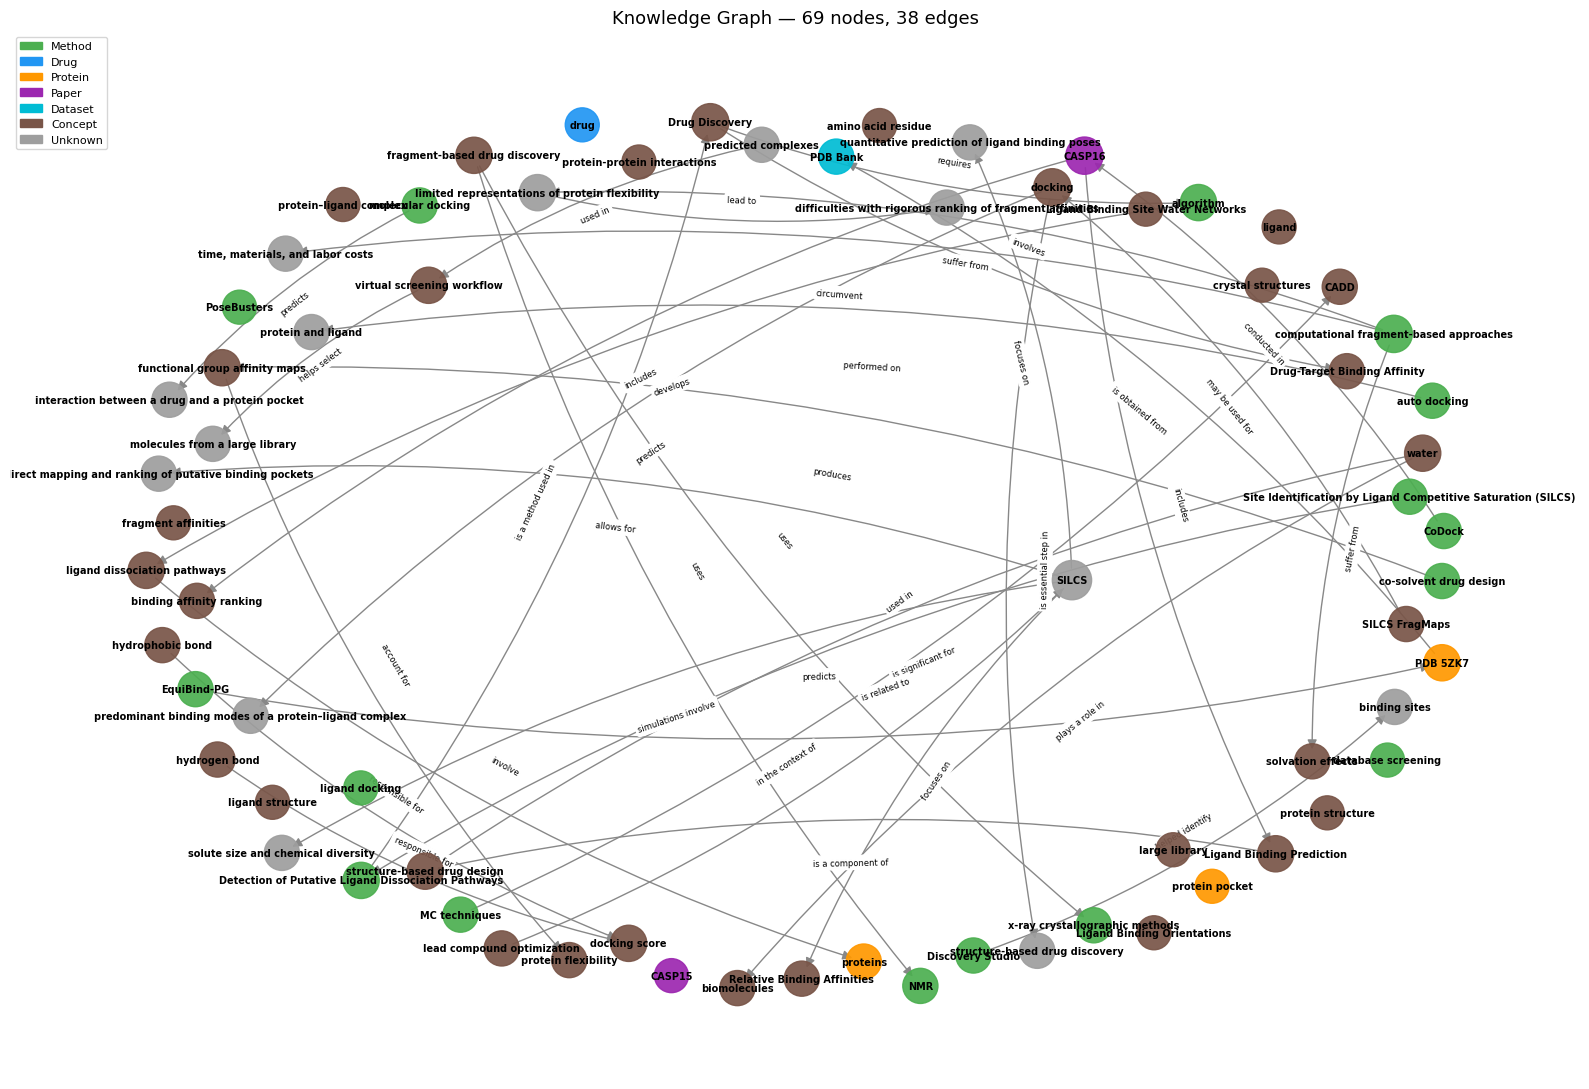

── Full KG, coloured by community (Louvain) ──


/var/folders/tc/fzx_pp_s3bn7kqwlqjg__1rm0000gn/T/ipykernel_83145/3261207961.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', max(n, 1))


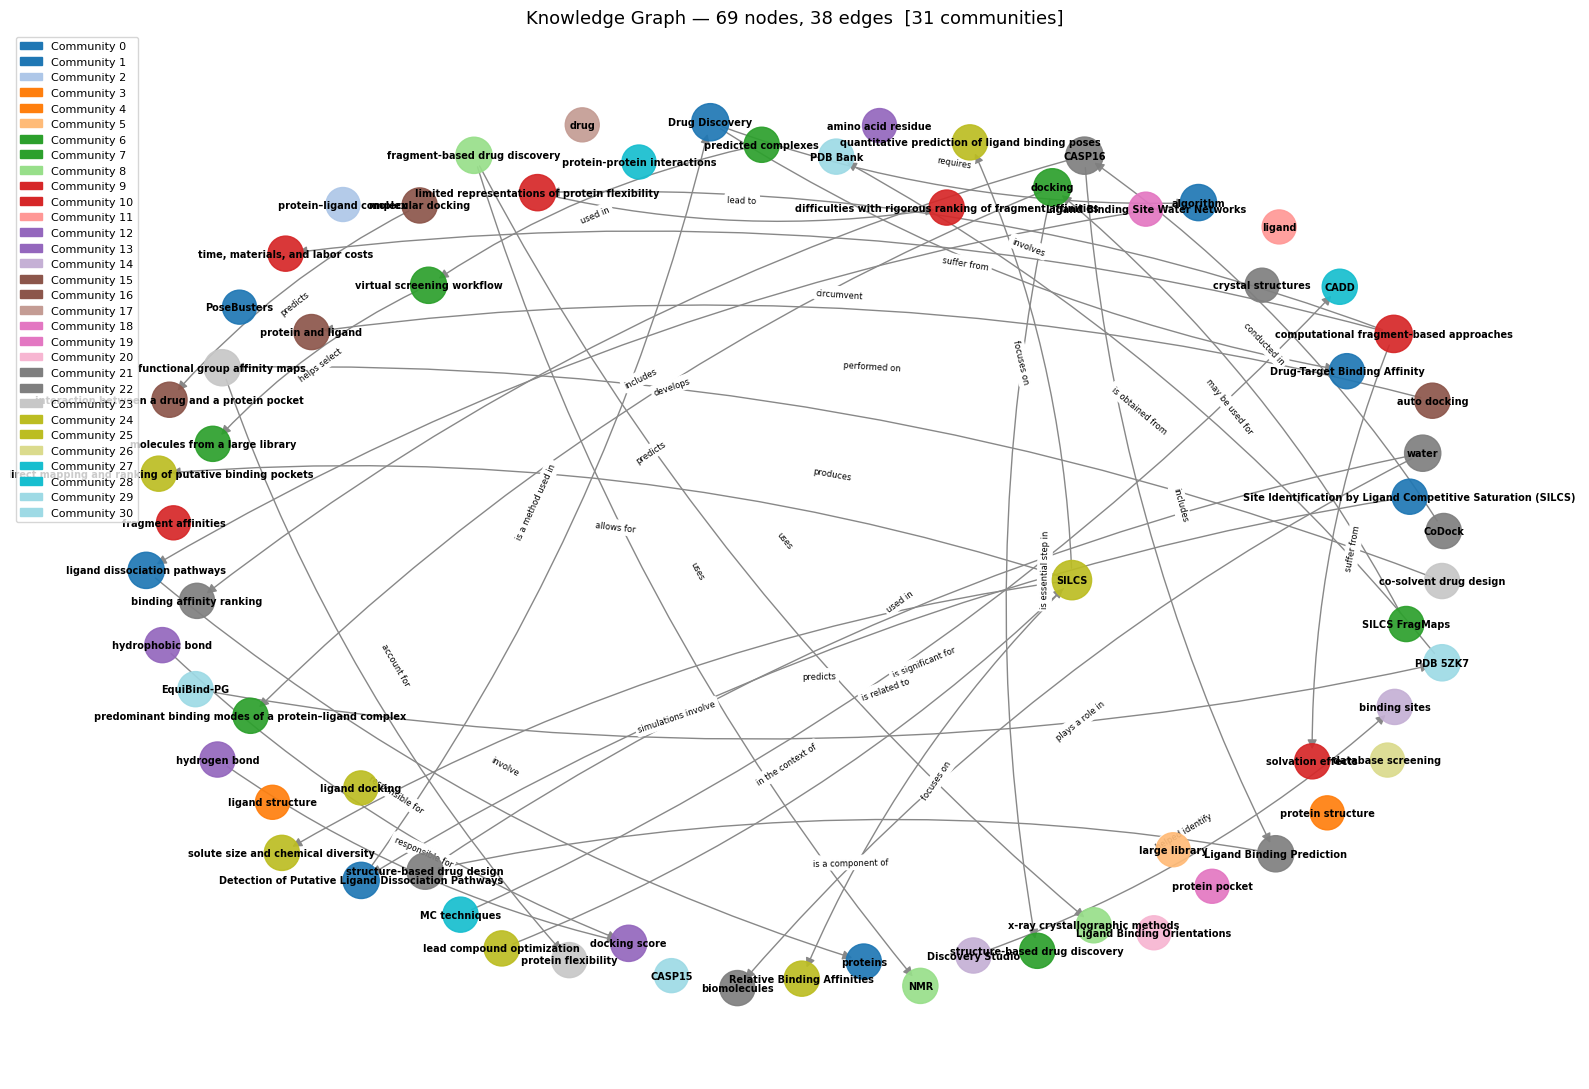

── Filtered KG: Methods + Drugs only ──


/var/folders/tc/fzx_pp_s3bn7kqwlqjg__1rm0000gn/T/ipykernel_83145/3261207961.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', max(n, 1))


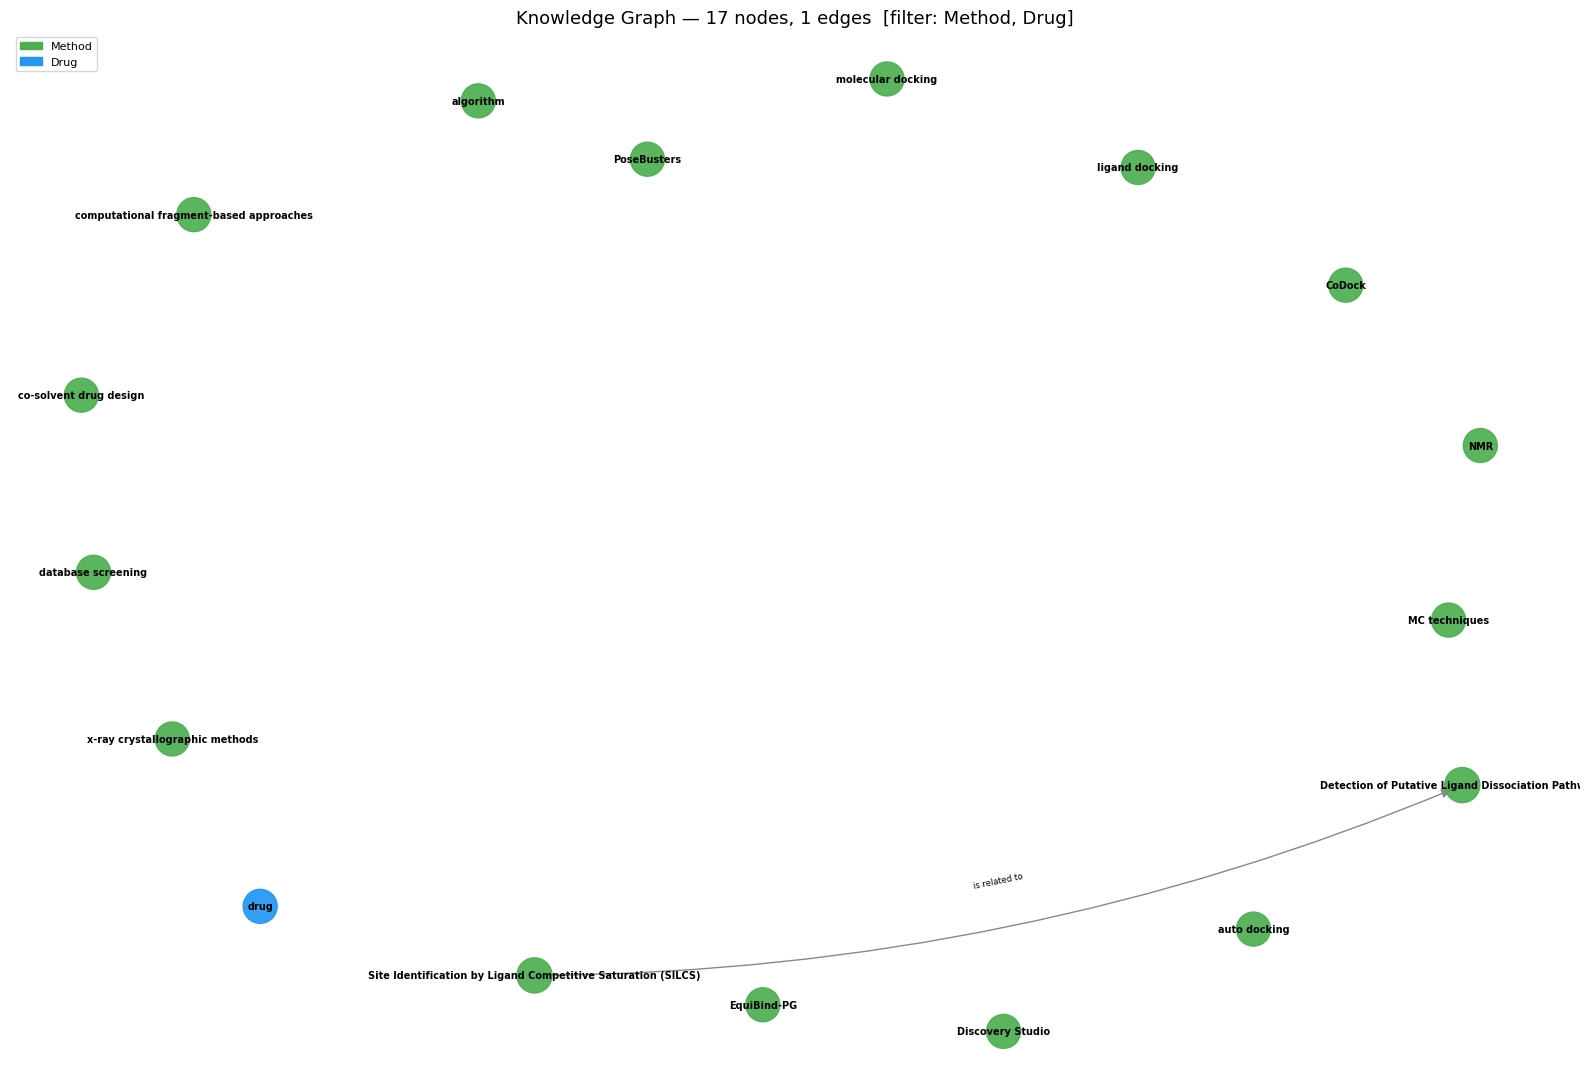


── KG Statistics ──
{'connected_components': 31,
 'density': 0.0081,
 'edges': 38,
 'entity_types': {'Concept': 32,
                  'Dataset': 1,
                  'Drug': 1,
                  'Method': 16,
                  'Paper': 2,
                  'Protein': 3,
                  'Unknown': 14},
 'largest_component_size': 7,
 'n_communities': 31,
 'nodes': 69,
 'top_nodes_by_degree': [{'degree': 5, 'node': 'SILCS'},
                         {'degree': 3, 'node': 'Drug Discovery'},
                         {'degree': 3, 'node': 'docking'},
                         {'degree': 3,
                          'node': 'computational fragment-based approaches'},
                         {'degree': 3, 'node': 'CASP16'},
                         {'degree': 2,
                          'node': 'Detection of Putative Ligand Dissociation '
                                  'Pathways'},
                         {'degree': 2, 'node': 'virtual screening workflow'},
                         {'d

In [80]:
import pprint

# ── Build KG from indexed content ─────────────────────────────────────────────
hits = tool_vector_search('protein ligand binding drug discovery', k=12)
for hit in hits['results']:
    tool_kg_extract(
        hit['content'],
        source_id=hit['metadata'].get('pmid') or hit['metadata'].get('title', '?')
    )

# ── Option B: load a local file first, then add it to the KG ─────────────────
# FILE_PATH = '~/Downloads/your_paper.pdf'           # ← change this
# tool_load_local_file(FILE_PATH)
# hits = tool_vector_search('your topic', k=8, filter_source='pdf')
# for hit in hits['results']:
#     tool_kg_extract(hit['content'], source_id=pathlib.Path(FILE_PATH).name)

# ─────────────────────────────────────────────────────────────────────────────
# Visualisation 1: colour by entity type (default)
# ─────────────────────────────────────────────────────────────────────────────
print('── Full KG, coloured by entity type ──')
tool_kg_visualize(backend='matplotlib')

# ─────────────────────────────────────────────────────────────────────────────
# Visualisation 2: colour by Louvain community
# ─────────────────────────────────────────────────────────────────────────────
print('── Full KG, coloured by community (Louvain) ──')
tool_kg_visualize(backend='matplotlib', color_by='community')

# ─────────────────────────────────────────────────────────────────────────────
# Visualisation 3: type filter — show only Methods and Drugs
# ─────────────────────────────────────────────────────────────────────────────
print('── Filtered KG: Methods + Drugs only ──')
tool_kg_visualize(backend='matplotlib', filter_types=['Method', 'Drug'])

# ─────────────────────────────────────────────────────────────────────────────
# Graph statistics
# ─────────────────────────────────────────────────────────────────────────────
print('\n── KG Statistics ──')
stats = tool_kg_stats()
pprint.pprint(stats)

# ─────────────────────────────────────────────────────────────────────────────
# N-hop neighbourhood query
# ─────────────────────────────────────────────────────────────────────────────
print('\n── Neighbourhood: SILCS (depth=2) ──')
pprint.pprint(tool_kg_search('SILCS', depth=2))

# ─────────────────────────────────────────────────────────────────────────────
# Shortest path between two entities
# ─────────────────────────────────────────────────────────────────────────────
print('\n── Shortest path: SILCS → hERG ──')
pprint.pprint(tool_kg_shortest_path('SILCS', 'hERG'))

# ─────────────────────────────────────────────────────────────────────────────
# Export the KG (three formats)
# ─────────────────────────────────────────────────────────────────────────────
print('\n── Export to JSON ──')
print(tool_kg_export('json'))

print('\n── Export to CSV ──')
print(tool_kg_export('csv'))

# Uncomment to export GraphML for Gephi / Neo4j:
# print(tool_kg_export('graphml'))

In [81]:
def run_conversation(questions: list[str], model: str = 'gpt-4o') -> None:
    """Multi-turn conversation — shared message history across turns."""
    messages = [{'role': 'system', 'content': SYSTEM_PROMPT}]

    for i, question in enumerate(questions):
        print(f'\n{"="*65}\nTURN {i+1}: {question}\n{"="*65}')
        messages.append({'role': 'user', 'content': question})

        for _ in range(12):
            response = client.chat.completions.create(
                model=model, messages=messages, tools=TOOLS, tool_choice='auto'
            )
            choice  = response.choices[0]
            message = choice.message
            messages.append(message)

            if choice.finish_reason == 'stop':
                print(f'\nANSWER: {message.content}')
                break

            if choice.finish_reason != 'tool_calls':
                break

            for tc in message.tool_calls:
                args       = json.loads(tc.function.arguments)
                result     = TOOL_REGISTRY.get(tc.function.name, lambda **_: {'error': 'unknown'})(**args)
                result_str = json.dumps(result)
                print(f'  [Tool] {tc.function.name}({json.dumps(args)[:80]})')
                print(f'       → {result_str[:200]}')
                messages.append({'role': 'tool', 'tool_call_id': tc.id, 'content': result_str})


run_conversation([
    'What is the SILCS-MC method for ligand binding prediction?',
    'How many papers have applied this to hERG cardiotoxicity? Give me key findings.',
    'What would be the next logical research direction based on these findings?'
])


TURN 1: What is the SILCS-MC method for ligand binding prediction?
  [Tool] pubmed_search({"query": "SILCS-MC method ligand binding prediction", "max_results": 5})
       → {"results": [{"pmid": "39636837", "title": "Modeling Ligand Binding Site Water Networks with Site Identification by Ligand Competitive Saturation: Impact on Ligand ", "abstract_snippet": "Appropriate 
  [Tool] fetch_and_index_paper({"pmid": "39636837"})
       → {"status": "already_indexed", "pmid": "39636837"}
  [Tool] vector_search({"query": "SILCS-MC method for ligand binding prediction", "filter_source": "ful)
       → {"results": [{"score": 0.7915, "content": "of the ligands under study. For example, the default approach for standard SILCS-MC is to use exhaustive MC sampling of ligands in a sphere of a radius of 5 

ANSWER: The SILCS-MC (Site Identification by Ligand Competitive Saturation - Monte Carlo) method is a computational technique designed to predict ligand binding poses and affinities in protein targ

## Key Takeaways

### What makes this agentic
- **Tool selection** — the model decides which databases to query per question
- **Adaptive retrieval** — full text fetched only for high-value papers
- **Progressive knowledge graph** — entities and relations accumulate across tool calls, with automatic deduplication and provenance tracking
- **Persistent vector DB** — all indexed content reused across turns; later questions are faster

### Tool inventory
| # | Tool | Source | Auto-indexes |
|---|------|--------|:---:|
| 1 | `pubmed_search` | NCBI E-utilities | — |
| 2 | `fetch_and_index_paper` | PMC full-text | ✓ |
| 3 | `arxiv_search` | arXiv API | ✓ |
| 4 | `semantic_scholar_search` | S2 Graph API | ✓ |
| 5 | `web_search` | DuckDuckGo | — |
| 6 | `fetch_url` | Any URL | ✓ |
| 7 | `vector_search` | ChromaDB | — |
| 8 | `crossref_lookup` | CrossRef API | — |
| 9 | `load_local_file` | PDF / PPTX / HTML / image | ✓ |
| 10 | `kg_extract` | Any text → NetworkX | — |
| 11 | `kg_search` | N-hop neighbourhood traversal | — |
| 12 | `kg_visualize` | matplotlib / pyvis · filter\_types · color\_by | — |
| 13 | `kg_shortest_path` | Directed + undirected path search | — |
| 14 | `kg_stats` | Density, communities, top nodes, relation types | — |
| 15 | `kg_export` | JSON / GraphML (Gephi) / CSV | — |

### Production improvements
- Swap `EphemeralClient` for `PersistentClient` to keep the vector DB across sessions
- Add a cross-encoder re-ranker on `vector_search` results (`cross-encoder/ms-marco-MiniLM-L-6-v2`)
- Use `text-embedding-3-large` instead of `all-MiniLM-L6-v2` for better recall
- Cache `pubmed_search` results by query string to avoid redundant API calls
- Persist the KG with `kg_export('graphml')` and reload via `nx.read_graphml()` between sessions